In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.metrics import f1_score, precision_score, recall_score

warnings.filterwarnings("ignore")

# ── Load data ──────────────────────────────────────────────────────────────
# Expects a CSV with at least a 'timestamp' and a 'Close' column.
# Replace the path below with your actual data path.
DATA_PATH = r'G:\Mi unidad\2026\Tesis\Códigos\Data\sp500_2015_to_2025_dollar_bars.csv'

data = pd.read_csv(DATA_PATH)
data['timestamp'] = pd.to_datetime(data['timestamp'])
data = data.set_index('timestamp').sort_index()
close = data['Close'].astype(float)

print(f"Loaded {len(close):,} bars  |  {close.index[0].date()} → {close.index[-1].date()}")


Loaded 2,048 bars  |  2017-01-11 → 2025-12-30


Crossover events detected: 44
  Bullish (+1): 22
  Bearish (-1): 22


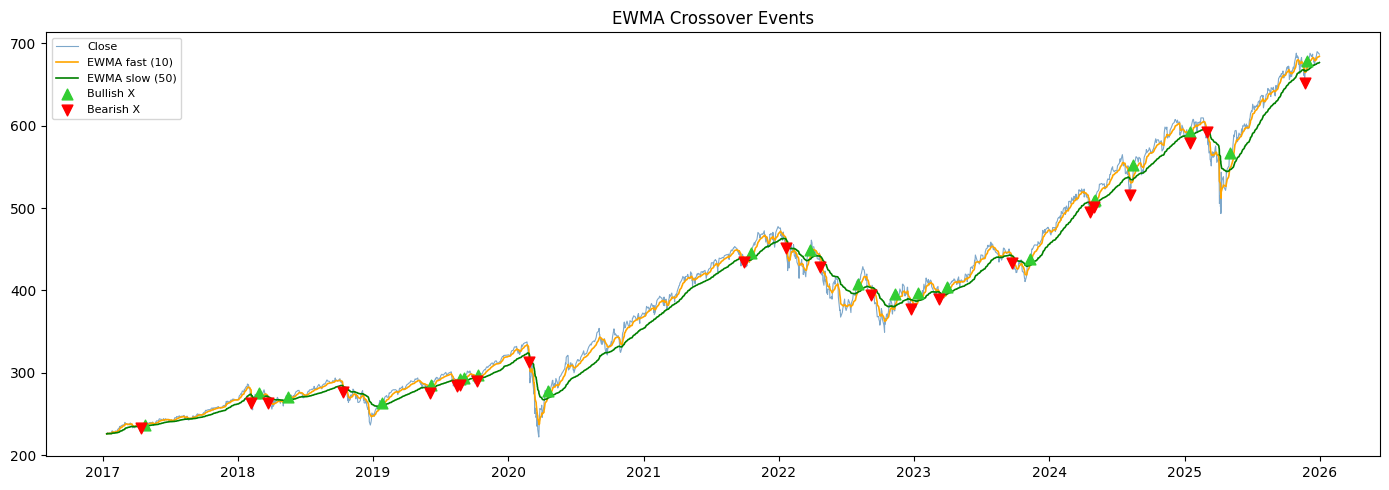

In [7]:
# ── Parameters ────────────────────────────────────────────────────────────
FAST_SPAN = 10
SLOW_SPAN = 50
BURN_IN   = SLOW_SPAN          # discard early EWMA transient

def get_ewma_crossover_events(close: pd.Series,
                              fast_span: int = FAST_SPAN,
                              slow_span: int = SLOW_SPAN,
                              burn_in: int  = BURN_IN) -> pd.DataFrame:
    """
    Detect EWMA crossover events on *close*.

    Returns a DataFrame with columns:
        fast_ewma  – fast EWMA value at the crossing bar
        slow_ewma  – slow EWMA value at the crossing bar
        side       – +1 (bullish) or -1 (bearish)
    indexed by the crossing timestamp.
    """
    fast = close.ewm(span=fast_span, adjust=False).mean()
    slow = close.ewm(span=slow_span, adjust=False).mean()

    # Work only on post-burn-in data to avoid EWMA warm-up artefacts.
    fast = fast.iloc[burn_in:]
    slow = slow.iloc[burn_in:]

    diff      = fast - slow
    diff_prev = diff.shift(1)

    bullish = (diff_prev <= 0) & (diff > 0)
    bearish = (diff_prev >= 0) & (diff < 0)

    df = pd.DataFrame({'fast_ewma': fast, 'slow_ewma': slow})
    df['side'] = np.where(bullish, 1, np.where(bearish, -1, 0))
    return df[df['side'] != 0]


events_cross = get_ewma_crossover_events(close)
print(f"Crossover events detected: {len(events_cross)}")
print(f"  Bullish (+1): {(events_cross['side'] == 1).sum()}")
print(f"  Bearish (-1): {(events_cross['side'] == -1).sum()}")

# ── Quick diagnostic plot ─────────────────────────────────────────────────
fast_full = close.ewm(span=FAST_SPAN, adjust=False).mean()
slow_full = close.ewm(span=SLOW_SPAN, adjust=False).mean()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(close.index, close,     label='Close',            color='steelblue', lw=0.8, alpha=0.7)
ax.plot(fast_full.index, fast_full, label=f'EWMA fast ({FAST_SPAN})', color='orange',   lw=1.2)
ax.plot(slow_full.index, slow_full, label=f'EWMA slow ({SLOW_SPAN})', color='green',    lw=1.2)

bull = events_cross[events_cross['side'] ==  1]
bear = events_cross[events_cross['side'] == -1]
ax.scatter(bull.index, close.loc[bull.index], marker='^', color='limegreen', s=60, zorder=5, label='Bullish X')
ax.scatter(bear.index, close.loc[bear.index], marker='v', color='red',       s=60, zorder=5, label='Bearish X')

ax.set_title('EWMA Crossover Events')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


In [3]:
# ── Triple-barrier parameters ─────────────────────────────────────────────
PT_SL      = [1.0, 1.0]   # profit-take and stop-loss multipliers (symmetric)
MIN_RET    = 1e-4          # minimum target size to keep an event
VOL_SPAN   = 20            # EWM span for daily volatility estimate
NUM_BARS   = 63           # vertical barrier width (bars)

# ── Daily EWMA volatility as the barrier target ───────────────────────────
daily_ret = close.pct_change()
trgt = daily_ret.ewm(span=VOL_SPAN, adjust=False).std()
trgt.name = 'trgt'

# ── Vertical barrier: t1[i] = timestamp NUM_BARS bars after event i ───────
tEvents = events_cross.index
event_pos  = close.index.get_indexer(tEvents, method='backfill')
valid      = event_pos != -1
last_pos   = len(close) - 1
barrier_pos = np.minimum(event_pos[valid] + NUM_BARS, last_pos)
t1 = pd.Series(close.index[barrier_pos], index=tEvents[valid])

print(f"Volatility target — median: {trgt.median():.4f}  "
      f"| mean: {trgt.mean():.4f}")
print(f"Vertical barrier: {NUM_BARS} bars")


Volatility target — median: 0.0090  | mean: 0.0100
Vertical barrier: 63 bars


In [4]:
def apply_barriers(close: pd.Series,
                   events: pd.DataFrame,
                   pt_sl) -> pd.DataFrame:
    """
    For each event in *events* (columns: t1, trgt, side) compute the
    first time the price path hits the profit-take (pt) or stop-loss (sl)
    barrier, or reaches the vertical barrier (t1).

    Returns a DataFrame with columns:
        pt     – timestamp of first PT hit (NaT if not hit)
        sl     – timestamp of first SL hit (NaT if not hit)
    """
    out = pd.DataFrame(index=events.index,
                       columns=['pt', 'sl'],
                       dtype='datetime64[ns]')

    for loc, ev in events.iterrows():
        try:
            loc_pos = close.index.get_loc(loc)
        except KeyError:
            continue

        end_time = ev['t1'] if pd.notna(ev['t1']) else close.index[-1]
        end_pos  = close.index.get_indexer([end_time], method='bfill')[0]
        start_pos = loc_pos + 1

        if start_pos > end_pos:
            continue

        path = close.iloc[start_pos : end_pos + 1]
        if len(path) < 2:
            continue

        entry  = path.iloc[0]
        rets   = (path.iloc[1:] / entry - 1.0) * ev['side']

        if pt_sl[0] > 0:
            hit = rets[rets >=  pt_sl[0] * ev['trgt']]
            if not hit.empty:
                out.loc[loc, 'pt'] = hit.index[0]

        if pt_sl[1] > 0:
            hit = rets[rets <= -pt_sl[1] * ev['trgt']]
            if not hit.empty:
                out.loc[loc, 'sl'] = hit.index[0]

    out['pt'] = pd.to_datetime(out['pt'])
    out['sl'] = pd.to_datetime(out['sl'])
    return out


def get_events(close: pd.Series,
               tEvents,
               pt_sl,
               trgt: pd.Series,
               min_ret: float,
               t1: pd.Series,
               side: pd.Series) -> pd.DataFrame:
    """
    Build the triple-barrier event table.

    Returns a DataFrame indexed by event time with columns:
        t1     – vertical barrier timestamp
        trgt   – volatility target
        side   – trade direction (+1 long, -1 short)
        t_hit  – earliest barrier timestamp (PT, SL, or t1)
        label  – +1 (PT hit), -1 (SL hit), 0 (vertical barrier / timeout)
    """
    tEvents = pd.Index(tEvents).sort_values()

    # Align target and side; drop events with no valid target.
    trgt_  = trgt.reindex(tEvents).dropna()
    trgt_  = trgt_[trgt_ > min_ret]

    ev = pd.DataFrame(index=trgt_.index)
    ev['t1']   = t1.reindex(ev.index)
    ev['trgt'] = trgt_
    ev['side'] = side.reindex(ev.index).fillna(1.0)

    hits = apply_barriers(close, ev, pt_sl)

    # t_hit = earliest of {t1, pt, sl}
    candidates = pd.concat([ev['t1'], hits['pt'], hits['sl']], axis=1)
    candidates.columns = ['t1', 'pt', 'sl']
    ev['t_hit'] = candidates.stack(dropna=True).groupby(level=0).min()

    # Label: which barrier was hit first?
    def _label(row):
        if pd.isna(row['t_hit']):
            return 0
        if pd.notna(hits.loc[row.name, 'pt']) and row['t_hit'] == hits.loc[row.name, 'pt']:
            return int(row['side'])    # PT hit → correct direction
        if pd.notna(hits.loc[row.name, 'sl']) and row['t_hit'] == hits.loc[row.name, 'sl']:
            return -int(row['side'])   # SL hit → wrong direction
        return 0                       # vertical barrier

    ev['label'] = ev.apply(_label, axis=1)
    return ev


# ── Build side series from crossover events ───────────────────────────────
side_series = events_cross['side'].astype(float)

labeled = get_events(
    close   = close,
    tEvents = tEvents,
    pt_sl   = PT_SL,
    trgt    = 3*trgt,
    min_ret = MIN_RET,
    t1      = t1,
    side    = side_series,
)

print(f"Labeled events: {len(labeled)}")
print(labeled['label'].value_counts().rename({1:'PT (+1)', -1:'SL (-1)', 0:'Vertical (0)'}))
print("\nSample:")
print(labeled.head(8).to_string())


Labeled events: 142
label
PT (+1)         92
SL (-1)         46
Vertical (0)     4
Name: count, dtype: int64

Sample:
                                     t1      trgt  side               t_hit  label
timestamp                                                                         
2017-01-23 18:29:00 2017-03-27 15:39:00  0.009428  -1.0 2017-01-25 20:14:00      1
2017-01-24 19:39:00 2017-03-28 20:02:00  0.009793   1.0 2017-02-09 16:50:00      1
2017-01-31 20:14:00 2017-04-07 13:02:00  0.011662  -1.0 2017-02-09 16:50:00      1
2017-02-03 15:52:00 2017-04-12 19:19:00  0.011096   1.0 2017-02-13 21:00:00      1
2017-03-09 15:02:00 2017-05-26 14:49:00  0.009797  -1.0 2017-03-21 18:40:00     -1
2017-03-15 18:13:00 2017-06-06 17:49:00  0.011324   1.0 2017-03-21 15:07:00     -1
2017-03-20 15:03:00 2017-06-12 14:09:00  0.010476  -1.0 2017-04-25 15:01:00      1
2017-03-30 20:14:00 2017-06-29 16:14:00  0.012020   1.0 2017-04-26 14:42:00      1


Strategy total return : +169.22%
Buy & Hold total return: +204.07%
Number of position changes: 143


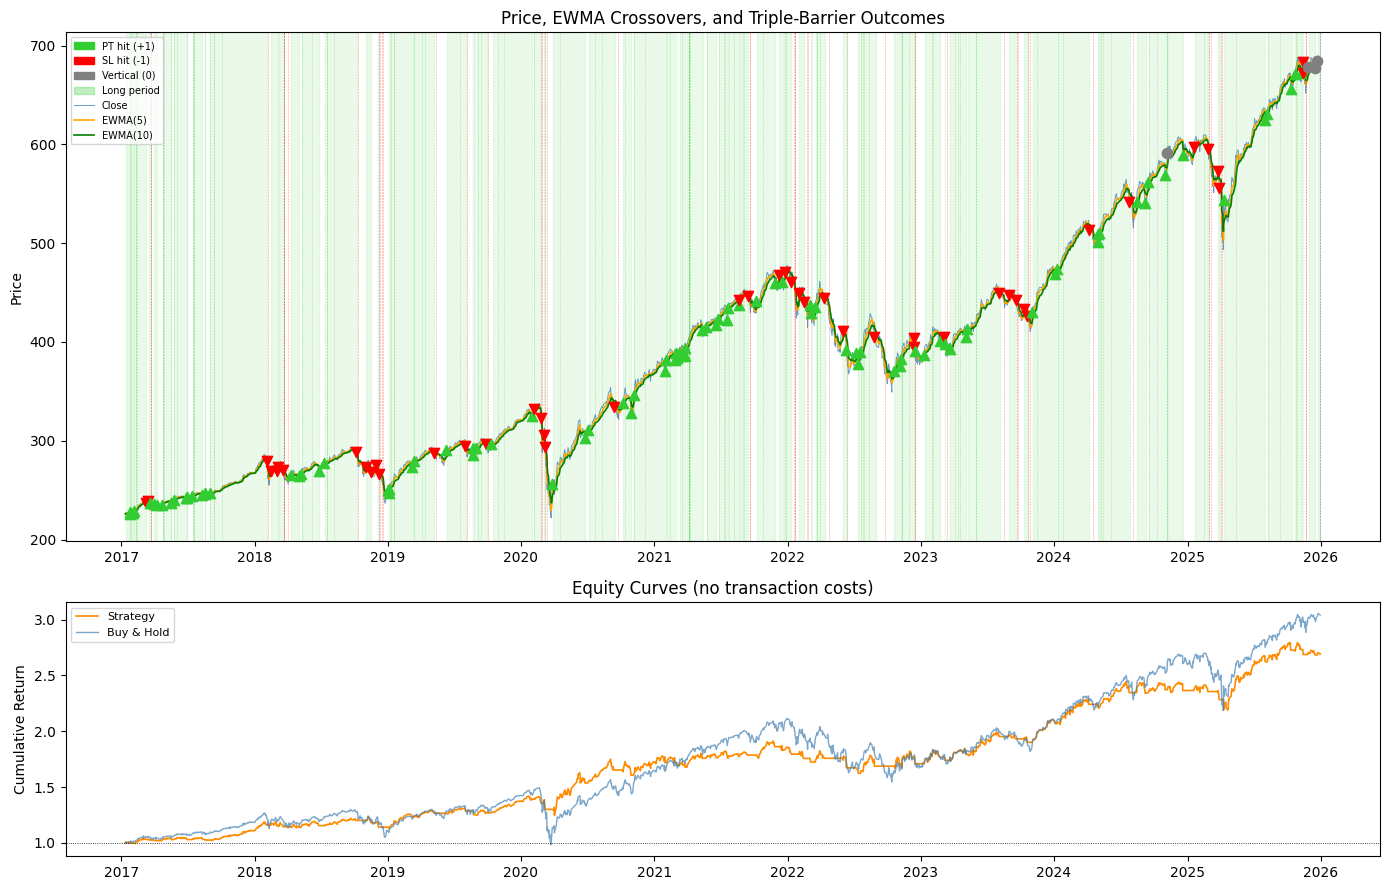

In [5]:
# ── Position series ───────────────────────────────────────────────────────
# Rule: enter on bullish crossover (+1), exit / flip on bearish (-1).
# When a new signal overlaps an active trade the position updates immediately.
# Bearish crossover → go flat (0), NOT short.

signal_series = events_cross['side'].reindex(close.index).fillna(0).astype(int)
signal_series.iloc[0] = 1  # assume we start in a long position before any crossover


# Replace -1 (bearish) with 0 (flat) for position purposes.
marker = signal_series.replace(-1, 0).astype(float)
marker[signal_series == -1] = 0.0   # explicit exit to flat

# Forward-fill: hold position until next signal.
position = marker.where(signal_series != 0).ffill().fillna(0).astype(int)

# Shift by 1 bar to avoid look-ahead bias (execute on the bar after signal).
entry_pos = position.shift(1).fillna(0).astype(int)

# ── Returns ───────────────────────────────────────────────────────────────
price_ret    = close.pct_change().fillna(0)
strategy_ret = entry_pos * price_ret

cum_strat  = (1 + strategy_ret).cumprod()
cum_bh     = (1 + price_ret).cumprod()

total_strat = cum_strat.iloc[-1] - 1
total_bh    = cum_bh.iloc[-1]    - 1
n_trades    = (entry_pos.diff().abs() > 0).sum()

print(f"Strategy total return : {total_strat:+.2%}")
print(f"Buy & Hold total return: {total_bh:+.2%}")
print(f"Number of position changes: {n_trades}")

# ── Plot ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 9),
                         gridspec_kw={'height_ratios': [2, 1]})

# ── Top panel: price + EWMA + events ─────────────────────────────────────
ax = axes[0]
fast_full = close.ewm(span=FAST_SPAN, adjust=False).mean()
slow_full = close.ewm(span=SLOW_SPAN, adjust=False).mean()

ax.plot(close.index,     close,     lw=0.7, color='steelblue', alpha=0.8, label='Close')
ax.plot(fast_full.index, fast_full, lw=1.2, color='orange',    label=f'EWMA({FAST_SPAN})')
ax.plot(slow_full.index, slow_full, lw=1.2, color='green',     label=f'EWMA({SLOW_SPAN})')

# Shade background by active long position.
in_long = False
start_long = None
for ts, pos in entry_pos.items():
    if pos == 1 and not in_long:
        start_long = ts
        in_long    = True
    elif pos != 1 and in_long:
        ax.axvspan(start_long, ts, color='limegreen', alpha=0.10)
        in_long = False
if in_long:
    ax.axvspan(start_long, close.index[-1], color='limegreen', alpha=0.10)

# Mark barrier outcomes on entry points.
for ts, row in labeled.iterrows():
    col = {1: 'limegreen', -1: 'red', 0: 'grey'}[row['label']]
    mk  = {1: '^',          -1: 'v',  0: 'o'}[row['label']]
    ax.scatter(ts, close.loc[ts], marker=mk, color=col, s=55, zorder=6)
    # Vertical barrier line.
    if pd.notna(row['t_hit']):
        ax.axvline(row['t_hit'], color=col, lw=0.4, ls='--', alpha=0.4)

pt_patch  = mpatches.Patch(color='limegreen', label='PT hit (+1)')
sl_patch  = mpatches.Patch(color='red',       label='SL hit (-1)')
vb_patch  = mpatches.Patch(color='grey',      label='Vertical (0)')
long_patch = mpatches.Patch(color='limegreen', alpha=0.3, label='Long period')
ax.legend(handles=[pt_patch, sl_patch, vb_patch, long_patch] +
          ax.get_legend_handles_labels()[0][:3], fontsize=7)
ax.set_title('Price, EWMA Crossovers, and Triple-Barrier Outcomes')
ax.set_ylabel('Price')

# ── Bottom panel: equity curves ───────────────────────────────────────────
ax2 = axes[1]
ax2.plot(cum_strat.index, cum_strat, label='Strategy',    color='darkorange', lw=1.2)
ax2.plot(cum_bh.index,    cum_bh,    label='Buy & Hold',  color='steelblue',  lw=1.0, alpha=0.7)
ax2.axhline(1.0, color='black', lw=0.6, ls=':')
ax2.set_title('Equity Curves (no transaction costs)')
ax2.set_ylabel('Cumulative Return')
ax2.legend(fontsize=8)

plt.tight_layout()
plt.show()


To understand them, we first define the outcomes based on the Confusion Matrix:True Positive (TP): The meta-model said "Bet" ($ŷ=1$), and the primary signal hit the profit target ($y=1$).False Positive (FP): The meta-model said "Bet" ($ŷ=1$), but the primary signal hit the stop-loss or timed out ($y=0$).False Negative (FN): The meta-model said "No Bet" ($ŷ=0$), but the primary signal would have hit the profit target ($y=1$).True Negative (TN): The meta-model said "No Bet" ($ŷ=0$), and the primary signal indeed failed ($y=0$).1. Precision (The Reliability)Precision answers: "Of all the trades the meta-model told me to take, how many were actually winners?"In finance, precision is often the most critical metric because it directly relates to your hit rate and the avoidance of losing trades.$$Precision = \frac{TP}{TP + FP}$$High Precision: Means you have very few "False Alarms." When the model says to trade, it is usually right.Low Precision: Means you are taking many trades that end up hitting the stop-loss.2. Recall (The Coverage)Recall answers: "Of all the potential winning opportunities the primary model generated, how many did the meta-model actually catch?"Recall measures your "opportunity capture."$$Recall = \frac{TP}{TP + FN}$$High Recall: Means you are not "missing out" on many winners. You are betting on most of the signals that would have been profitable.Low Recall: Means your filter is very strict. You might be skipping many profitable trades to ensure that the ones you do take are safe.3. F1-Score (The Balance)The F1-Score is the harmonic mean of Precision and Recall. It provides a single number to measure the performance of your filter by penalizing extreme values of either metric.$$F1 = 2 \cdot \frac{Precision \times Recall}{Precision + Recall}$$Why use it? If you have a model with 100% Precision but it only takes 1 trade a year (0.01% Recall), the model is practically useless for generating returns. Conversely, if you take every trade (100% Recall) but lose money on half (50% Precision), your risk management is poor. The F1-Score tells you how well you are balancing these two forces.

In [6]:
# ── Overlap-weighted F1 ───────────────────────────────────────────────────
# Each event is treated independently (barrier outcome is not updated by
# overlapping signals). Events are weighted by the fraction of their
# barrier window that is NOT overlapped by the next event.
#
# Formally, let event i have window [t_i, t_hit_i].  If event j starts at
# t_j with t_i < t_j < t_hit_i, the unique (non-overlapped) length is:
#
#       unique_i = (t_j - t_i) / (t_hit_i - t_i)
#
# If no overlap exists, unique_i = 1.  This mirrors López de Prado's
# average-uniqueness weighting (AFML §4.3).

def compute_overlap_weights(labeled: pd.DataFrame) -> pd.Series:
    """
    Returns a weight in (0, 1] for each event reflecting the fraction of
    its barrier window that is not covered by the next event's entry.
    """
    ev = labeled[['t_hit']].copy().sort_index()
    ev['t_next'] = ev.index.to_series().shift(-1).values   # next event entry

    weights = []
    for ts, row in ev.iterrows():
        if pd.isna(row['t_hit']):
            weights.append(1.0)
            continue
        window = (row['t_hit'] - ts).total_seconds()
        if window <= 0:
            weights.append(1.0)
            continue
        if pd.notna(row['t_next']) and row['t_next'] < row['t_hit']:
            overlap = (row['t_hit'] - row['t_next']).total_seconds()
            w = max(0.0, 1.0 - overlap / window)
        else:
            w = 1.0
        weights.append(w)

    return pd.Series(weights, index=ev.index, name='weight')


weights = compute_overlap_weights(labeled)

# Drop events with no barrier hit (label == 0 from vertical barrier can be
# treated as 'no signal' for F1; include or exclude depending on your
# research design — here we include them as negative class).
y_true = labeled['label'].values          # +1 or -1 or 0
y_pred = labeled['side'].astype(int).values  # signal direction (+1 or -1)

# Binarise: did the signal predict the correct direction?
# Correct = 1 if label == side, else 0.
y_true_bin = (y_true == y_pred).astype(int)
y_pred_bin = np.ones(len(y_true_bin), dtype=int)   # we always take the signal

from sklearn.metrics import precision_score, recall_score
w = weights.values

precision_unweighted = precision_score(y_true_bin, y_pred_bin, zero_division=0)
recall_unweighted = recall_score(y_true_bin, y_pred_bin, zero_division=0)
f1_unweighted = f1_score(y_true_bin, y_pred_bin, zero_division=0)
precision_weighted = precision_score(y_true_bin, y_pred_bin, sample_weight=w, zero_division=0)
recall_weighted = recall_score(y_true_bin, y_pred_bin, sample_weight=w, zero_division=0)
f1_weighted   = f1_score(y_true_bin, y_pred_bin,
                         sample_weight=w, zero_division=0)

hit_rate       = y_true_bin.mean()
hit_rate_w     = np.average(y_true_bin, weights=w)

print("=" * 50)
print("Triple-Barrier F1 Evaluation")
print("=" * 50)
print(f"  Events evaluated          : {len(labeled)}")
print(f"  Mean overlap weight       : {w.mean():.4f}")
print(f"  Hit rate (unweighted)     : {hit_rate:.4f}")
print(f"  Hit rate (weighted)       : {hit_rate_w:.4f}")
print(f"  Precision (unweighted)    : {precision_unweighted:.4f}")
print(f"  Recall (unweighted)       : {recall_unweighted:.4f}")
print(f"  Precision (weighted)      : {precision_weighted:.4f}")
print(f"  Recall (weighted)         : {recall_weighted:.4f}")
print(f"  F1 (unweighted)           : {f1_unweighted:.4f}")
print(f"  F1 (overlap-weighted)     : {f1_weighted:.4f}")
print()
print("Label distribution:")
print(labeled['label'].value_counts()
      .rename({1:'PT (+1)', -1:'SL (-1)', 0:'Vertical (0)'}))
print()
print("Weight distribution (quantiles):")
print(weights.quantile([0.10, 0.25, 0.50, 0.75, 0.90]).round(4))


Triple-Barrier F1 Evaluation
  Events evaluated          : 142
  Mean overlap weight       : 0.6927
  Hit rate (unweighted)     : 0.5352
  Hit rate (weighted)       : 0.6125
  Precision (unweighted)    : 0.5352
  Recall (unweighted)       : 1.0000
  Precision (weighted)      : 0.6125
  Recall (weighted)         : 1.0000
  F1 (unweighted)           : 0.6972
  F1 (overlap-weighted)     : 0.7597

Label distribution:
label
PT (+1)         92
SL (-1)         46
Vertical (0)     4
Name: count, dtype: int64

Weight distribution (quantiles):
0.10    0.1442
0.25    0.3922
0.50    0.8273
0.75    1.0000
0.90    1.0000
Name: weight, dtype: float64
